In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
data = pd.read_csv('data/energy_hourly.csv')
data = data.dropna()

In [14]:
# Get all regions
regions = data['insee_region'].unique()
print(regions)
region = 11 # IDF
data = data[data['insee_region'] == region]

[11 24 27 28 32 44 52 53 75 76 84 93]


In [15]:
data['datetime_hour'] = pd.to_datetime(data['datetime_hour'])
data

,datetime_hour,insee_region,conso_elec_mw,conso_gaz_mw,datetime,temperature_2m,precipitation,relative_humidity_2m,dew_point_2m,apparent_temperature,...,wind_direction_10m,wind_direction_100m,wind_gusts_10m,et0_fao_evapotranspiration,weather_code,snow_depth,vapour_pressure_deficit,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,date
0,2013-01-01 00:00:00,11,0.0,0.0,2013-01-01 00:00:00,8.2,0.6,84,5.7,3.5,...,205,207,48.6,0.02,53,0.0,0.17,8.2,0.384,2013-01-01
12,2013-01-01 01:00:00,11,17956.0,0.0,2013-01-01 01:00:00,8.0,0.8,86,5.9,3.4,...,206,208,47.9,0.02,53,0.0,0.15,8.0,0.395,2013-01-01
24,2013-01-01 02:00:00,11,16728.0,0.0,2013-01-01 02:00:00,8.0,0.8,87,6.0,3.5,...,208,210,46.8,0.01,53,0.0,0.14,7.9,0.405,2013-01-01
36,2013-01-01 03:00:00,11,15998.0,0.0,2013-01-01 03:00:00,8.0,1.0,88,6.1,3.7,...,210,213,45.7,0.01,55,0.0,0.13,7.8,0.416,2013-01-01
48,2013-01-01 04:00:00,11,15107.0,0.0,2013-01-01 04:00:00,8.0,1.1,89,6.3,3.8,...,213,216,45.7,0.01,55,0.0,0.12,7.8,0.426,2013-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1191408,2024-04-29 20:00:00,11,15079.0,5039.0,2024-04-29 20:00:00,15.8,0.0,67,9.7,14.7,...,180,187,20.5,0.08,3,0.0,0.59,15.3,0.327,2024-04-29
1191420,2024-04-29 21:00:00,11,14444.0,4937.0,2024-04-29 21:00:00,14.4,0.0,72,9.5,13.2,...,162,168,10.8,0.04,3,0.0,0.45,14.5,0.326,2024-04-29
1191432,2024-04-29 22:00:00,11,13875.0,4369.0,2024-04-29 22:00:00,13.8,0.0,76,9.6,11.9,...,161,166,20.5,0.02,3,0.0,0.38,13.9,0.326,2024-04-29
1191444,2024-04-29 23:00:00,11,13852.0,3902.0,2024-04-29 23:00:00,12.9,0.0,80,9.5,11.3,...,170,172,20.5,0.01,3,0.0,0.30,13.3,0.326,2024-04-29


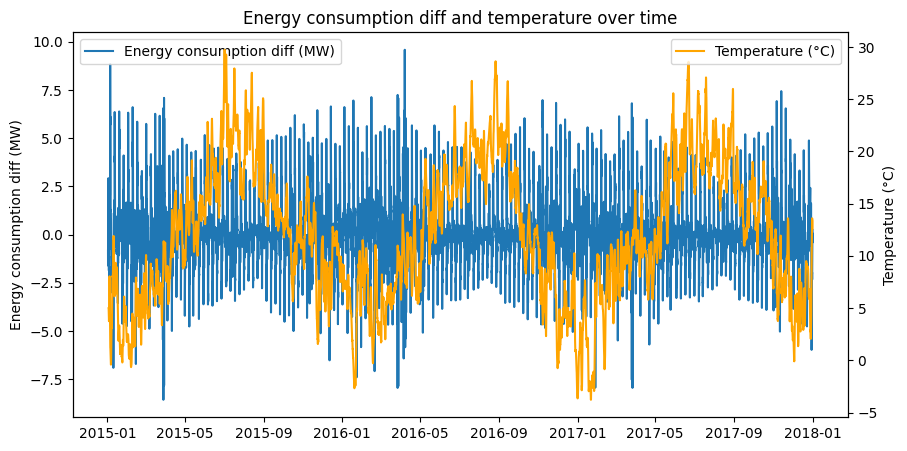

In [58]:
START_DATE = pd.to_datetime('2015-01-01')
END_DATE = pd.to_datetime('2018-01-01')

timeseries = data[(data['datetime_hour'] >= START_DATE) & (data['datetime_hour'] <= END_DATE)]
timeseries['conso_elec_mw_diff'] = timeseries['conso_elec_mw'].diff(periods=24)
timeseries = timeseries.set_index('datetime_hour')
timeseries = timeseries.sort_index()
timeseries = timeseries.dropna()

y = timeseries.index
c = timeseries['conso_elec_mw'] / 1000
c_diff = timeseries['conso_elec_mw_diff'] / 1000
# set temperature to max of last day 
t = timeseries['temperature_2m'].rolling(window=24).mean()

plt.figure(figsize=(10, 5))
plt.plot(y, c_diff, label='Energy consumption diff (MW)')
plt.ylabel('Energy consumption diff (MW)')
plt.legend(loc='upper left')

ax2 = plt.twinx()
ax2.plot(y, t, color='orange', label='Temperature (°C)')
ax2.set_ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.title('Energy consumption diff and temperature over time')
ax2.legend(loc='upper right')

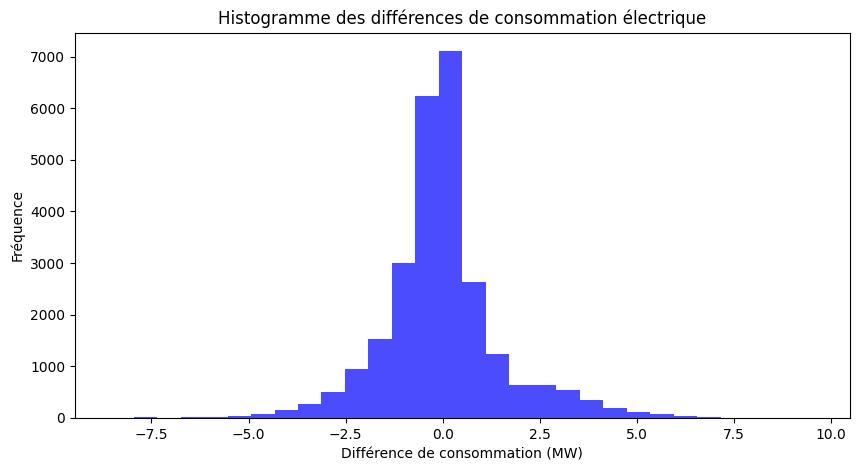

In [17]:
# Plot histogram of c_diff
plt.figure(figsize=(10, 5))
plt.hist(c_diff.dropna(), bins=30, alpha=0.7, color='blue')
plt.title('Histogramme des différences de consommation électrique')
plt.xlabel('Différence de consommation (MW)')
plt.ylabel('Fréquence')
plt.show()

Evaluating with sigma=0.1, threshold_y=[8, 15, 20, 200], seq=[1], order=1
0.41056889817841896
Evaluating with sigma=0.325, threshold_y=[8, 15, 20, 200], seq=[1], order=1
0.410564992148817
Evaluating with sigma=0.55, threshold_y=[8, 15, 20, 200], seq=[1], order=1
0.410564649268205
Evaluating with sigma=0.775, threshold_y=[8, 15, 20, 200], seq=[1], order=1
0.4105645392371412
Evaluating with sigma=1.0, threshold_y=[8, 15, 20, 200], seq=[1], order=1
0.41056448723014194
Evaluating with sigma=0.1, threshold_y=[8, 15, 20, 200], seq=[], order=1
0.41101209313795456
Evaluating with sigma=0.325, threshold_y=[8, 15, 20, 200], seq=[], order=1
0.4110091452953338
Evaluating with sigma=0.55, threshold_y=[8, 15, 20, 200], seq=[], order=1
0.41100862235994173
Evaluating with sigma=0.775, threshold_y=[8, 15, 20, 200], seq=[], order=1
0.41100840425869467
Evaluating with sigma=1.0, threshold_y=[8, 15, 20, 200], seq=[], order=1
0.411008284603839
Evaluating with sigma=0.1, threshold_y=[8, 15, 20, 200], seq=[1

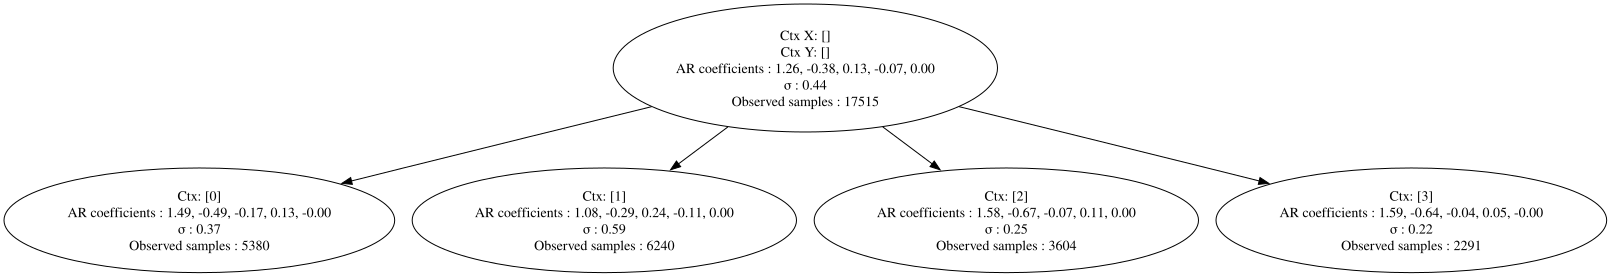

In [ ]:
from ctw.models import BivariateARTreeBis, Quantizer
from ctw.tree import view_tree
import numpy as np

train_proportion = 2/3
train_range = 0, int(len(c_diff) * train_proportion)
test_range = int(len(c_diff) * train_proportion), len(c_diff) - 1

threshold_x = np.linspace(c_diff.min(), c_diff.max(), 15)
threshold_y = [8, 15, 20, 200]

def evaluate(sigma, threshold_y, seq, order) :
    x_quantizer = Quantizer(thresholds=threshold_x)
    y_quantizer = Quantizer(thresholds=threshold_y)
    btree = BivariateARTreeBis(quantizer_seq=seq, x_quantizer=x_quantizer, y_quantizer=y_quantizer, order=order, constant_term=True, beta=0.9, sigma=sigma)
    for i in range(1):
        for i in range(*train_range):
            x = c_diff.iloc[i]
            y = t.iloc[i]
            btree.observe(x_new=x, y_new=y)
    view_tree(btree.tree, quantizer_seq=seq, x_quantizer=x_quantizer, y_quantizer=y_quantizer, min_observed_samples=0)
    predictions = []
    truth = []
    regimes = []
    for i in range(*test_range):
        x_history = c_diff.iloc[i-order + 1:i+1].to_list()
        y_history = t.iloc[i-order + 1:i+1].to_list()
        pred, regime = btree.predict(x_history=x_history, y_history=y_history)
        predictions.append(pred)
        regimes.append(regime)
        truth.append(c_diff.iloc[i+1])

    # Compute rmse
    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(predictions, truth))
    return rmse, btree, x_quantizer, y_quantizer, regimes

results = {}
for order in range(1, 5) :
    for seq in [[1], []] :
        for sigma in np.linspace(0.1, 1, 5) :
            print(f'Evaluating with sigma={sigma}, threshold_y={threshold_y}, seq={seq}, order={order}')
            rmse, btree, x_quantizer, y_quantizer, regimes = evaluate(sigma=sigma, threshold_y=threshold_y, seq=seq, order=order)
            results[(sigma, tuple(seq), tuple(threshold_y), order)] = rmse, btree, x_quantizer, y_quantizer, regimes
            print(rmse)

# Get best results
best_params = min(results, key=lambda x: results[x][0])
print(f'Best params: sigma={best_params[0]}, seq={best_params[1]}, threshold_y={best_params[2]}, order={best_params[3]} with RMSE={results[best_params][0]}')
best_btree = results[best_params][1]
best_x_quantizer = results[best_params][2]
best_y_quantizer = results[best_params][3]
view_tree(best_btree.tree, quantizer_seq=seq, x_quantizer=best_x_quantizer, y_quantizer=best_y_quantizer, min_observed_samples=0)


In [19]:
sorted_results = sorted(results.items(), key=lambda x: x[1][0])
print("Top 5 results:")
for i in range(5):
    params, (rmse, _, _, _) = sorted_results[i]
    print(f'Rank {i+1}: sigma={params[0]}, seq={params[1]}, threshold_y={params[2]}, order={params[3]} with RMSE={rmse}')

Top 5 results:
Rank 1: sigma=1.0, seq=(1,), threshold_y=(8, 15, 20, 200), order=4 with RMSE=0.3654172652449839
Rank 2: sigma=0.775, seq=(1,), threshold_y=(8, 15, 20, 200), order=4 with RMSE=0.36541914089545585
Rank 3: sigma=0.55, seq=(1,), threshold_y=(8, 15, 20, 200), order=4 with RMSE=0.3654265026431174
Rank 4: sigma=0.325, seq=(1,), threshold_y=(8, 15, 20, 200), order=4 with RMSE=0.3654619960600785
Rank 5: sigma=0.1, seq=(1,), threshold_y=(8, 15, 20, 200), order=4 with RMSE=0.36594195163604787


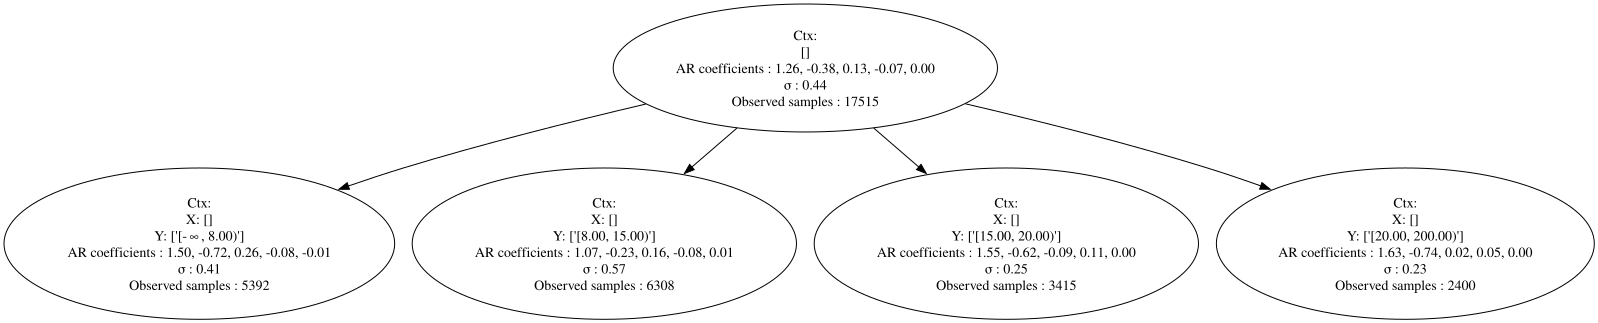

In [34]:
# Get best results
x_quantizer = Quantizer([0])
y_quantizer = Quantizer([8, 15, 20, 200])
best_tree = BivariateARTreeBis(quantizer_seq=[1], x_quantizer=x_quantizer, y_quantizer=y_quantizer, order=4, constant_term=True, beta=0.9, sigma=1)

for i in range(1):
    for i in range(*train_range):
        x = c_diff.iloc[i]
        y = t.iloc[i]
        best_tree.observe(x_new=x, y_new=y)

view_tree(best_tree.tree, quantizer_seq=[1], x_quantizer=x_quantizer, y_quantizer=y_quantizer, min_observed_samples=0)

In [38]:
# Predict
predictions = []
truth = []
regimes = []
for i in range(*test_range):
    x_history = c_diff.iloc[i-order + 1:i+1].to_list()
    y_history = t.iloc[i-order + 1:i+1].to_list()
    pred, regime = best_tree.predict(x_history=x_history, y_history=y_history)
    predictions.append(pred)
    regimes.append(regime)
    truth.append(c_diff.iloc[i+1])

regime_map = {regime: i for i, regime in enumerate(set(regimes))}
regimes = [regime_map[r] for r in regimes]
## MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(predictions, truth)
print(f'MSE: {mse}')
## MAE
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(predictions, truth)
print(f'MAE: {mae}')

MSE: 0.13663823174507594
MAE: 0.20728527357363097


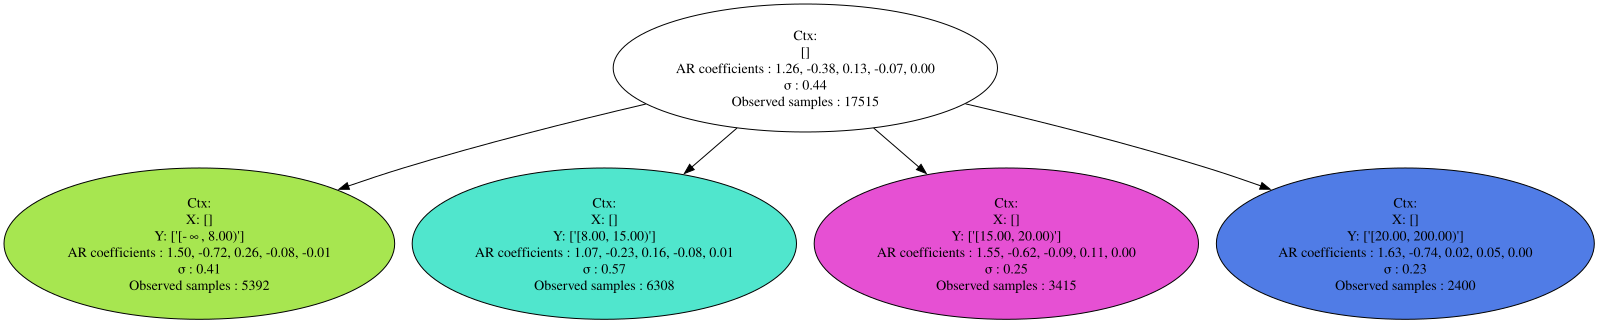

In [40]:
view_tree(best_tree.tree, quantizer_seq=[1], x_quantizer=x_quantizer, y_quantizer=y_quantizer, min_observed_samples=0, context_to_index=regime_map)

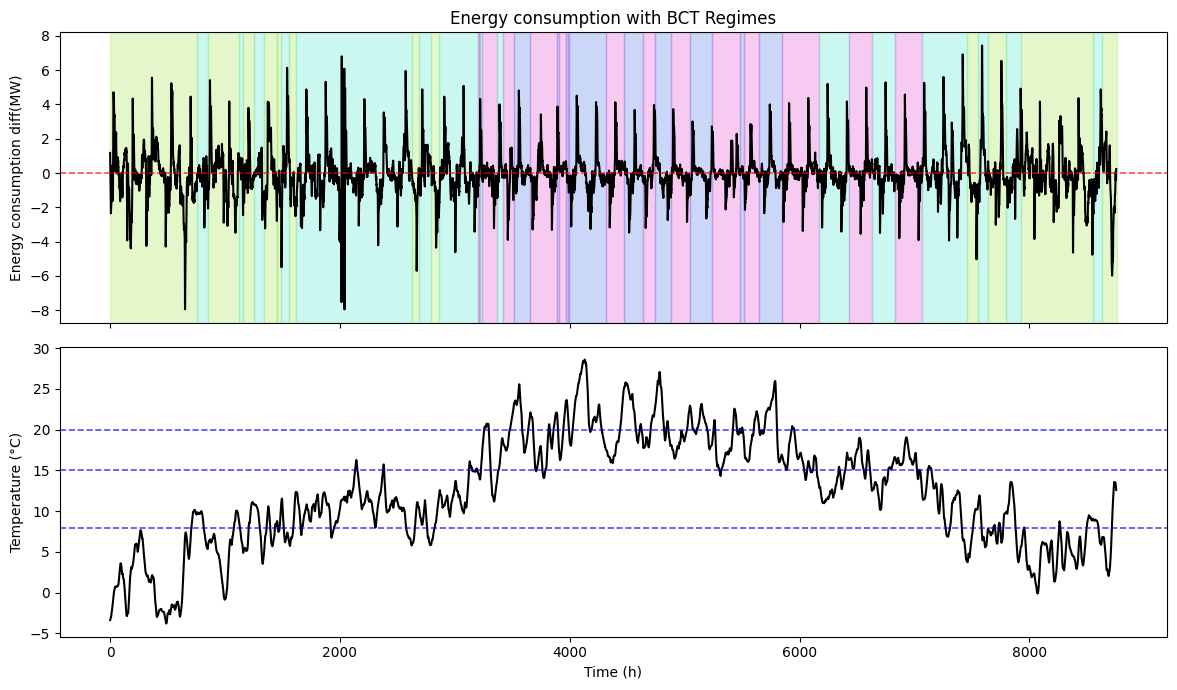

In [47]:
x = c_diff.iloc[test_range[0]+order:test_range[1]+1]
y = t.iloc[test_range[0]+order:test_range[1]+1]
from utils import plot_time_series
plot_time_series(np.array([x, y]), title="Energy consumption with BCT Regimes", ylabel="Energy consumption diff(MW)", thresholds=[[0], threshold_y[:-1]], list_regimes=regimes,xlabel="Time (h)", xlabel2="Time (h)", ylabel2="Temperature (°C)")

In [43]:
# Evaluate naive rmse
from sklearn.metrics import mean_squared_error
naive_predictions = c_diff.shift(1).iloc[test_range[0]:test_range[1]]
naive_truth = c_diff.iloc[test_range[0]:test_range[1]]
# MSE
naive_mse = mean_squared_error(naive_predictions, naive_truth)
# MAE
naive_mae = np.mean(np.abs(naive_predictions - naive_truth))
print(f'Naive MSE: {naive_mse}')
print(f'Naive MAE: {naive_mae}')

Naive MSE: 0.17269111952054794
Naive MAE: 0.22893573059360728


In [ ]:
# Evaluate best model on test set
best_btree = results[best_params][1]
predictions = []
actuals = []
for i in range(*test_range):
    x_history = c_diff.iloc[i-best_params[3] + 1:i+1].to_list()
    y_history = t.iloc[i-best_params[3] + 1:i+1].to_list()
    pred = best_btree.predict(x_history=x_history, y_history=y_history)
    predictions.append(pred)
    actuals.append(c_diff.iloc[i+1])

mse = np.mean((np.array(predictions) - np.array(actuals))**2)
print(f"CTW in-sample MSE: {mse}")
mae = np.mean(np.abs(np.array(predictions) - np.array(actuals)))
print(f"CTW in-sample MAE: {mae:.6f}")

CTW in-sample MSE: 0.13352977773912295
CTW in-sample MAE: 0.206706


In [ ]:
## AR model
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(c_diff, lags=4).fit()
predictions_ar = model.predict(start=4, end=len(c_diff)-1)
# MSE
mse_ar = np.mean((c_diff[4:] - predictions_ar) ** 2)
# MAE
mae_ar = np.mean(np.abs(c_diff[4:] - predictions_ar))
print(f"AR(4) in-sample MSE: {mse_ar:.6f}")
print(f"AR(4) in-sample MAE: {mae_ar:.6f}")

AR(4) in-sample MSE: 0.179225
AR(4) in-sample MAE: 0.210992


/Users/foxy/Documents/CS/3A/projet/CTW/.env/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [ ]:
from utils import plot_time_series
plot_time_series(predictions, actuals, title="CTW Predictions vs Actuals", ylabel="Conso élec diff (MW)")
